## Data Visualizations

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_norm = pd.read_csv("data/normalized_university_student_mental_health_indicators.csv")
stress_norm = pd.read_csv("data/normalized_student_stress_factors.csv")

## Chart 1:

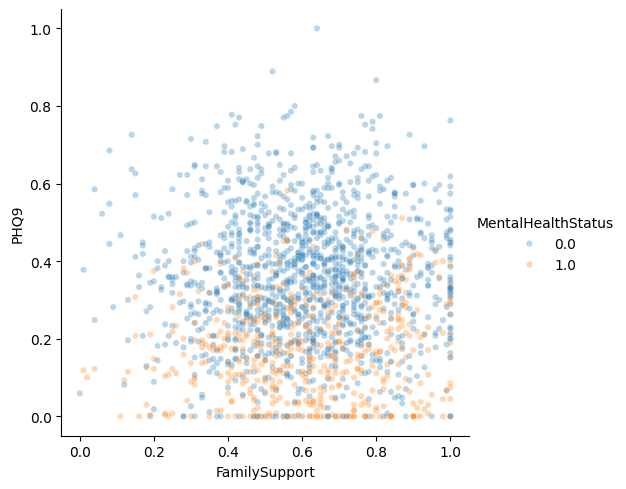

In [2]:
#Scatterplot comparing family support and PHQ9
sns.relplot(
    data=data_norm,
    x='FamilySupport',
    y='PHQ9',
    hue='MentalHealthStatus',
    kind='scatter',
    alpha=0.3,
    s=20
)
plt.savefig("chart1.png", bbox_inches='tight')
plt.show()

## Observations

The scatterplot shows a dense concentration of observations, with most points clustered at lower PHQ9 values (approximately between 1 and 5). As PHQ9 increases, the points become more spread out and less dense, indicating fewer individuals with higher PHQ9 scores.

Overall, there is no clear linear relationship between FamilySupport and PHQ9; instead, the points form a broad cloud without a strong directional pattern. Within this distribution, MentalHealthStatus categories (a binary variable where 0 represents lower or normal mental health status and 1 represents elevated or higher-risk mental health status based on dataset-defined thresholds) show some partial separation. One category (yellow) is more concentrated in the lower PHQ9 range, while another category (blue) appears more frequently in the higher PHQ9 range. However, there is still substantial overlap between the groups, and no distinct boundary separates them.

This suggests that while MentalHealthStatus is associated with PHQ9 to some extent, FamilySupport alone does not show a strong or clearly visible relationship with PHQ9 in this visualization. The overlap and diffuse clustering indicate that mental health outcomes are likely influenced by multiple factors rather than a single variable.

## Chart 2:

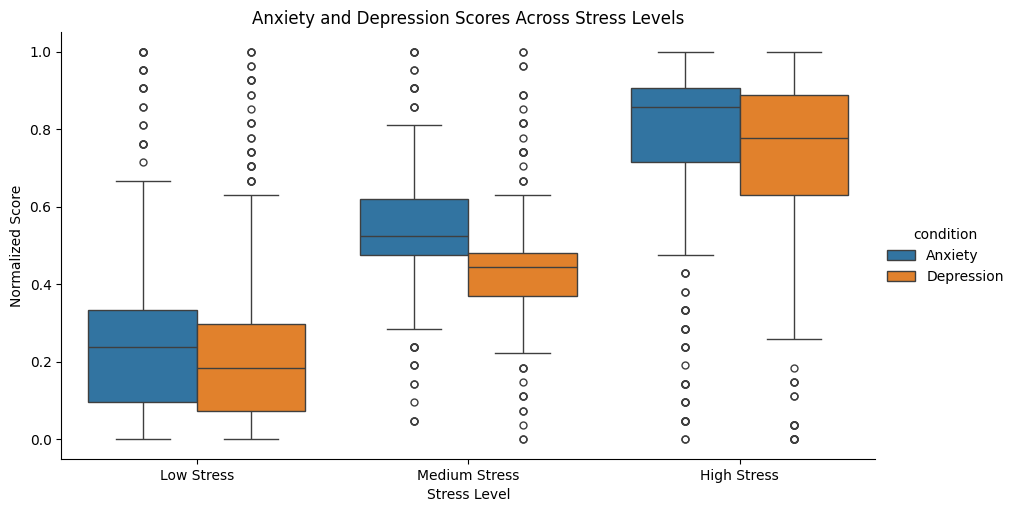

In [3]:
plot_stress = stress_norm.copy()
plot_stress['stress_label'] = plot_stress['stress_level'].map(
    {0.0: 'Low Stress', 0.5: 'Medium Stress', 1.0: 'High Stress'}
)
plot_melted = pd.melt(
    plot_stress,
    id_vars=['stress_label'],
    value_vars=['anxiety_level', 'depression'],
    var_name='condition',
    value_name='score'
)
plot_melted['condition'] = plot_melted['condition'].map(
    {'anxiety_level': 'Anxiety', 'depression': 'Depression'}
)
sns.catplot(
    x='stress_label',
    y='score',
    hue='condition',
    kind='box',
    data=plot_melted,
    order=['Low Stress', 'Medium Stress', 'High Stress'],
    height=5,
    aspect=1.8
)

plt.title('Anxiety and Depression Scores Across Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Normalized Score')

plt.show()

### Observations:
The boxplot shows differences in anxiety and depression scores across low, medium, and high stress groups. In the low stress category, both anxiety and depression distributions have similar spread, but anxiety has a slightly higher median. Both variables appear right-skewed, with longer upper tails and outliers occurring on the higher end, indicating a small number of individuals with elevated scores despite low stress levels.

In the medium stress group, the distributions for anxiety and depression have comparable spread and whisker lengths. Both boxes are relatively centered within their whiskers, with outliers appearing on both the lower and upper ends. The median for anxiety is higher than that of depression, and while neither median is perfectly centered within the box, anxiety’s median lies slightly below the midpoint of the box, whereas depression’s median is slightly above it.

For the high stress group, both anxiety and depression scores are generally higher, with higher medians compared to the other stress categories. The distributions in this group show slight skewness with longer lower tails and outliers on the lower end. Depression scores are lower than anxiety scores within this group, although both remain elevated overall. The median for anxiety lies in the upper portion of the box, while the depression median is closer to the center. Overall, the plot suggests that higher stress levels are associated with higher anxiety and depression scores, with some variation in distribution shape across groups.

Both anxiety and depression scores increase across stress levels, with a similar upward trend, although depression appears slightly lower than anxiety within each group. Overall, the results suggest a clear positive association between stress level and both anxiety and depression scores, indicating that students experiencing higher stress tend to report poorer mental health outcomes. This supports the broader goal of understanding how different stress levels relate to variations in student well-being.

## Chart 3

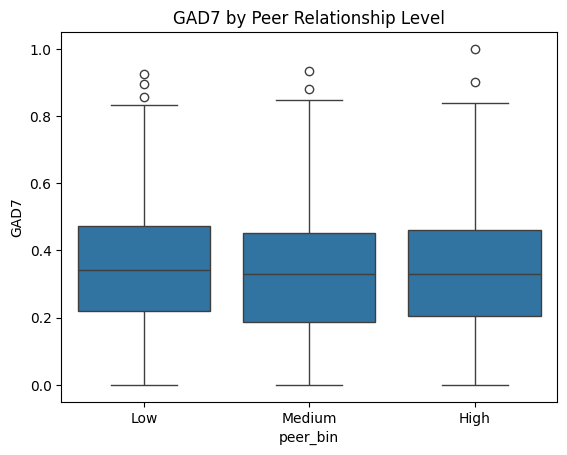

In [4]:
data_norm['peer_bin'] = pd.qcut(data_norm['PeerRelationship'], q=3, labels=['Low', 'Medium', 'High'])

sns.boxplot(
    data=data_norm,
    x='peer_bin',
    y='GAD7'
)

plt.title('GAD7 by Peer Relationship Level')
plt.show()